<a href="https://colab.research.google.com/github/SolisProcopioUriel/SimulacionII/blob/main/Estimacion_de_parametros_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parámetros ajustados:
q1 = 0.0000000000, q2 = 0.0000000000, q3 = 0.4262751309
 Tiempo (días)  Datos reales (cm³)  Modelo \(T(t)\) (cm³)
             0              0.1270                 0.1270
             3              0.1870                 0.2809
             6              0.2570                 0.4465
            10              0.3630                 0.5681
            13              0.4600                 0.6485
            17              0.6630                 0.7559
            20              0.8370                 0.8371
            24              1.0340                 0.9465
            27              1.3050                 1.0294


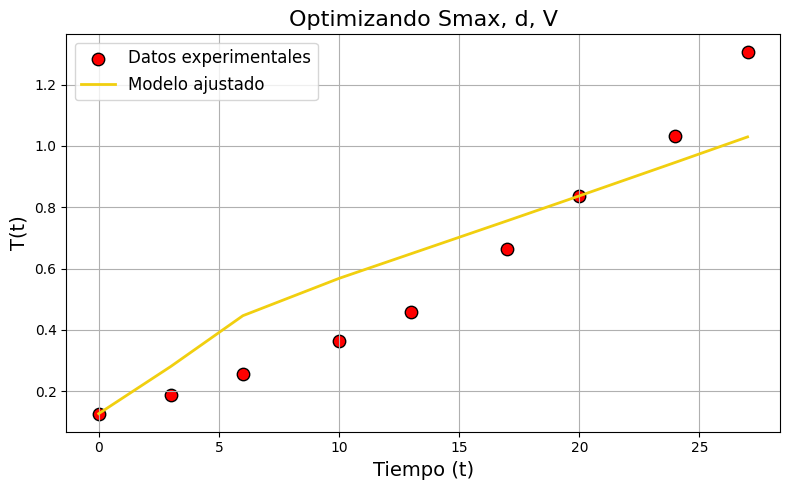

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import pandas as pd

# Datos experimentales
datos_reales = np.array([0.127, 0.187, 0.257, 0.363, 0.460, 0.663, 0.837, 1.034, 1.305])
tiempo_datos = np.array([0, 3, 6, 10, 13, 17, 20, 24, 27])

# Sistema de ecuaciones
def sistema(T, C, q1, q2, q3, g, Cmax, Cmin, Smax, d, V):
    dT_dt = q2 * C * T * (Smax - (T + V)) - (d * (Cmin - C)) * (1 / (1 + np.exp(-(Cmin - C)))) * T
    dC_dt = g * (Cmax - C) * V - q1 * C * T - q3 * C * T * (Smax - (T + V))
    return np.array([dT_dt, dC_dt])

# Método de Runge-Kutta de orden 4
def runge_kutta_4(T0, C0, t_final, h, q1, q2, q3, g, Cmax, Cmin, Smax, d, V):
    t_values = np.arange(0, t_final + h, h)
    T_values = np.zeros_like(t_values)
    C_values = np.zeros_like(t_values)
    T_values[0] = T0
    C_values[0] = C0

    for i in range(len(t_values) - 1):
        T, C = T_values[i], C_values[i]
        k1 = h * sistema(T, C, q1, q2, q3, g, Cmax, Cmin, Smax, d, V)
        k2 = h * sistema(T + 0.5 * k1[0], C + 0.5 * k1[1], q1, q2, q3, g, Cmax, Cmin, Smax, d, V)
        k3 = h * sistema(T + 0.5 * k2[0], C + 0.5 * k2[1], q1, q2, q3, g, Cmax, Cmin, Smax, d, V)
        k4 = h * sistema(T + k3[0], C + k3[1], q1, q2, q3, g, Cmax, Cmin, Smax, d, V)

        T_values[i + 1] = T + (k1[0] + 2*k2[0] + 2*k3[0] + k4[0]) / 6
        C_values[i + 1] = C + (k1[1] + 2*k2[1] + 2*k3[1] + k4[1]) / 6

    return t_values, T_values, C_values

#q1 = 0.0495192364
#q2 = 0.0011511878
#q3 = 0.0502966684
g = 5 #0.9468844470
Cmax = 4.5753757221
Cmin = 0.01
Smax = 5
d = 1
V = 0.005

def modelo(t, q1, q2, q3):
    T0, C0 = 0.127, 3.5
    t_vals, T_vals, _ = runge_kutta_4(T0, C0, max(t) + 1, 0.01, q1, q2, q3, g, Cmax, Cmin, Smax, d, V)
    interpolador = interp1d(t_vals, T_vals, kind='linear', fill_value="extrapolate")
    return interpolador(t)

# Valores iniciales y límites
p0 = [0.4, 2.0, 0.02]
limites = ([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf])

# Ajuste de parámetros
parametros_opt, _ = curve_fit(modelo, tiempo_datos, datos_reales, p0=p0, bounds=limites)
q1_opt, q2_opt, q3_opt = parametros_opt

# Evaluación final
t_eval, T_eval, _ = runge_kutta_4(0.127, 2, max(tiempo_datos)+1, 0.01, q1_opt, q2_opt, q3_opt, g, Cmax, Cmin, Smax, d, V)
interpolador_final = interp1d(t_eval, T_eval, kind='linear', fill_value="extrapolate")
T_final = interpolador_final(tiempo_datos)

# Imprimir parámetros ajustados
print("Parámetros ajustados:")
print(f"q1 = {q1_opt:.10f}, q2 = {q2_opt:.10f}, q3 = {q3_opt:.10f}")

tabla = pd.DataFrame({
    "Tiempo (días)": tiempo_datos,
    "Datos reales (cm³)": datos_reales,
    "Modelo \(T(t)\) (cm³)": T_final
})

print(tabla.to_string(index=False, float_format="%.4f"))


# Graficar resultados
plt.figure(figsize=(8, 5))
plt.scatter(tiempo_datos, datos_reales, color="red", label="Datos experimentales", edgecolors="black", s=80)
plt.plot(tiempo_datos, T_final, label="Modelo ajustado", color="#f1cf0f", linewidth=2)

plt.xlabel("Tiempo (t)", fontsize=14)
plt.ylabel("T(t)", fontsize=14)
plt.title("Optimizando Smax, d, V", fontsize=16)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()
plt.show()

#Gráfica cuando ptimizamos

  \begin{equation}
    q_2,~~q_3
  \end{equation}


1.   q1 = 0.0495192364
2.   **q2_opt = 0.0011511878**
3.   **q3_opt = 0.0502966684**
4.   g = 0.4337
5.   Cmax = 4
6.   Cmin = 2
7.   Smax = 5
8.   d = 0.2338
9.   V = 1.0

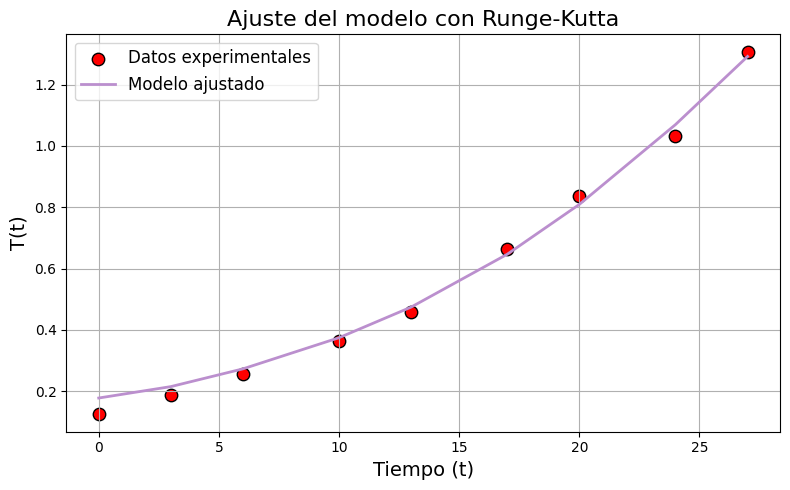

#Gráfica: Cuando optimizamos
  \begin{equation}
    g, ~~C_{max}, ~~C_{min}
  \end{equation}
  

1.   q1 = 0.0495192364
2.   q2 = 0.0011511878
3.   q3 = 0.0502966684
4.   **g_opt= 0.9468844470**
5.   **Cmax_opt = 4.5753757221**
6.   **Cmin_opt = 3.0564746609**
7.   Smax = 5
8.   d = 0.2338
9.   V = 1.0



  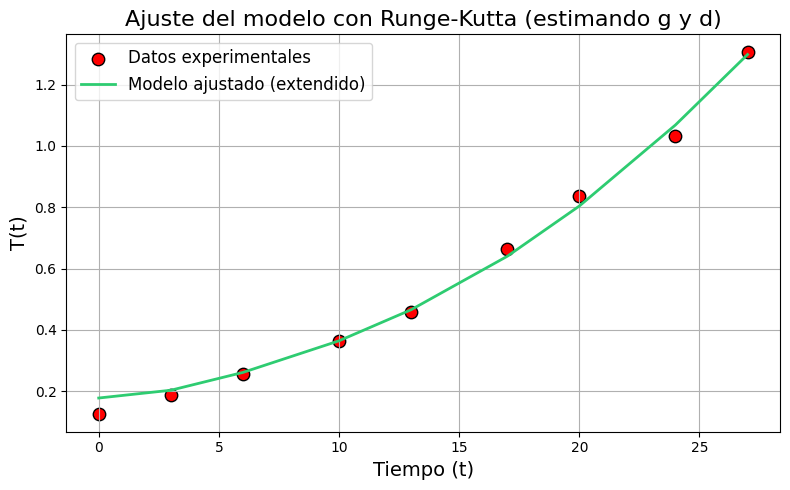

#Gráfica: Cuando optimizamos
  \begin{equation}
    g, ~~C_{max}, ~~C_{min}
  \end{equation}
  

1.   q1 = 0.0495192364
2.   q2 = 0.0011511878
3.   q3 = 0.0502966684
4.   g = 0.9468844470
5.   Cmax = 4.5753757221
6.   Cmin = 3.0564746609
7.   **Smax = 4.5860700596**  
8.   **d = 0.2533896910**
9.   **V = 0.7811955605**

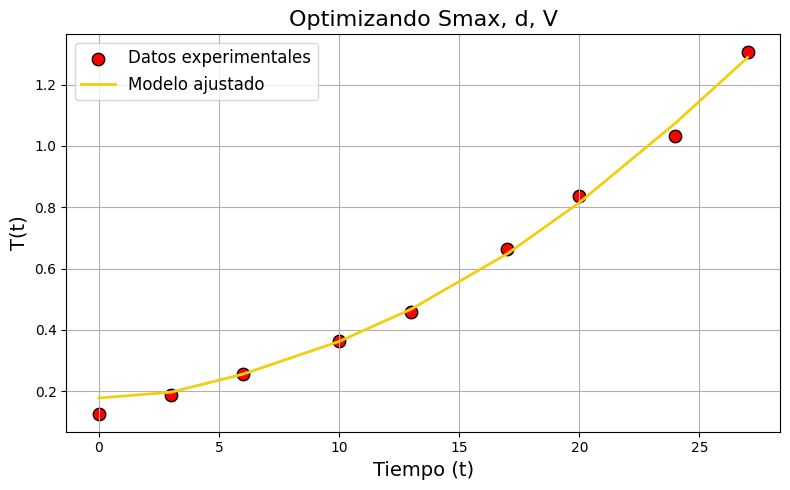